In [2]:
import duckdb
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# 直接从 DuckDB 读（数据第1周已经入库了）
con = duckdb.connect('../data/processed/ecommerce.db')
df = con.execute("SELECT * FROM behaviors").df()
df['date'] = pd.to_datetime(df['date'])

print(f"数据量: {len(df):,}")
print(f"日期范围: {df['date'].min()} ~ {df['date'].max()}")
df.head()

数据量: 4,999,325
日期范围: 2017-11-24 00:00:00 ~ 2017-12-03 00:00:00


,user_id,item_id,category_id,behavior_type,timestamp,date,hour
0,1,2268318,2520377,pv,2017-11-24 17:21:10,2017-11-24,17
1,1,2333346,2520771,pv,2017-11-24 22:15:33,2017-11-24,22
2,1,2576651,149192,pv,2017-11-25 01:21:25,2017-11-25,1
3,1,3830808,4181361,pv,2017-11-25 07:04:53,2017-11-25,7
4,1,4365585,2520377,pv,2017-11-25 07:49:06,2017-11-25,7


In [3]:
# 各行为类型总数
pv = int(df[df['behavior_type'] == 'pv'].shape[0])
fav = int(df[df['behavior_type'] == 'fav'].shape[0])
cart = int(df[df['behavior_type'] == 'cart'].shape[0])
buy = int(df[df['behavior_type'] == 'buy'].shape[0])

print(f"浏览(pv):     {pv:>12,}")
print(f"收藏(fav):    {fav:>12,}  ({fav/pv*100:.2f}%)")
print(f"加购(cart):   {cart:>12,}  ({cart/pv*100:.2f}%)")
print(f"下单(buy):    {buy:>12,}  ({buy/pv*100:.2f}%)")
print(f"\nPV → 收藏转化率: {fav/pv*100:.2f}%")
print(f"收藏 → 加购转化率: {cart/fav*100:.2f}%")
print(f"加购 → 下单转化率: {buy/cart*100:.2f}%")
print(f"整体 PV → 下单:    {buy/pv*100:.2f}%")


浏览(pv):        4,474,562
收藏(fav):         145,125  (3.24%)
加购(cart):        279,512  (6.25%)
下单(buy):         100,126  (2.24%)

PV → 收藏转化率: 3.24%
收藏 → 加购转化率: 192.60%
加购 → 下单转化率: 35.82%
整体 PV → 下单:    2.24%


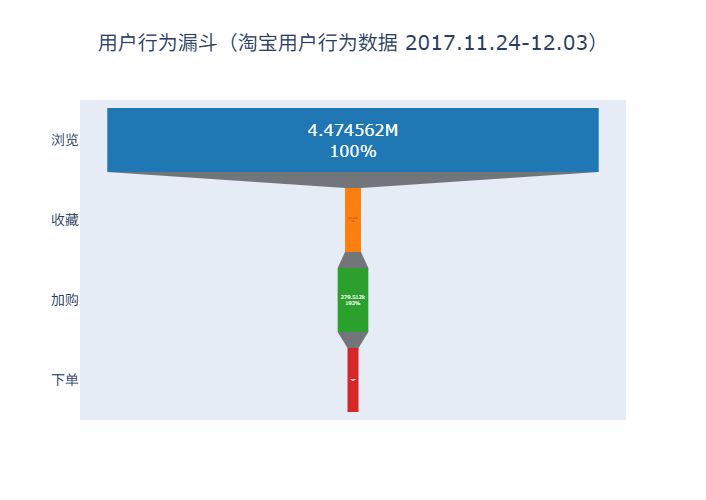

In [6]:
fig = go.Figure(go.Funnel(
    y=['浏览', '收藏', '加购', '下单'],
    x=[pv, fav, cart, buy],
    textposition='inside',
    textinfo='value+percent previous',
    textfont=dict(size=16),
    marker={'color': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']}
))

fig.update_layout(
    title='用户行为漏斗（淘宝用户行为数据 2017.11.24-12.03）',
    title_x=0.5,
    height=500,
    font=dict(size=14)
)
fig.show()


In [8]:
# 按天统计
daily = df.groupby(['date', 'behavior_type']).size().unstack(fill_value=0)
# 正确映射：列名顺序是 buy, cart, fav, pv
daily = daily[['pv', 'fav', 'cart', 'buy']]
daily.columns = ['浏览', '收藏', '加购', '下单']

daily['浏览→下单转化率'] = (daily['下单'] / daily['浏览'] * 100).round(2)
daily.head(10)

,浏览,收藏,加购,下单,浏览→下单转化率
date,,,,,
2017-11-24,53984,1905,3186,786,1.46
2017-11-25,465571,14887,28265,9934,2.13
2017-11-26,470120,15514,29344,10503,2.23
2017-11-27,446297,14562,27391,10707,2.40
2017-11-28,438180,14488,26957,10584,2.42
2017-11-29,459598,14920,28017,11043,2.40
2017-11-30,469964,14855,28820,11036,2.35
2017-12-01,502201,15760,32338,10757,2.14
2017-12-02,628700,20892,40530,12961,2.06


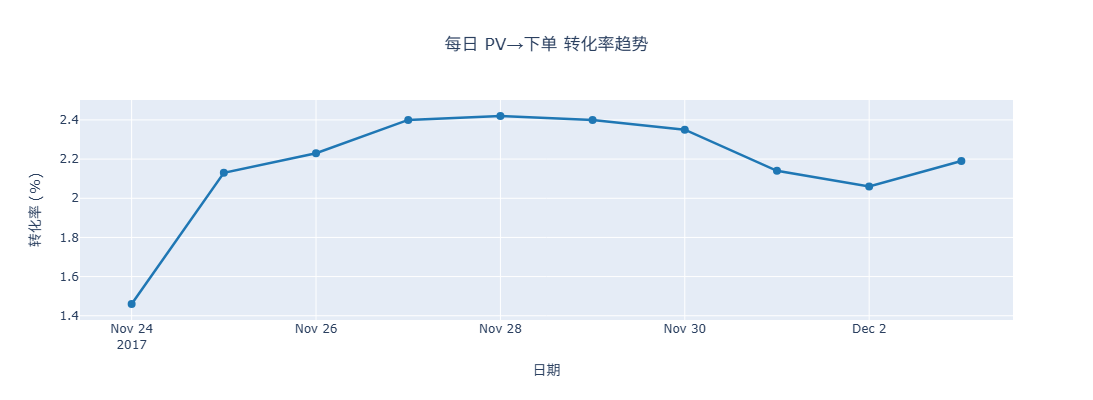

In [9]:
fig = px.line(daily, x=daily.index, y='浏览→下单转化率', markers=True,
              title='每日 PV→下单 转化率趋势')

fig.update_layout(title_x=0.5, height=400,
                  xaxis_title='日期', yaxis_title='转化率 (%)')
fig.update_traces(line=dict(color='#1f77b4', width=2.5),
                  marker=dict(size=8))
fig.show()

In [10]:
# Top 5 类目（PV最高）
top5 = df['category_id'].value_counts().head(5).index

# 每个类目计算漏斗
results = []
for cat in top5:
    cat_df = df[df['category_id'] == cat]
    pv = int((cat_df['behavior_type'] == 'pv').sum())
    fav = int((cat_df['behavior_type'] == 'fav').sum())
    cart = int((cat_df['behavior_type'] == 'cart').sum())
    buy = int((cat_df['behavior_type'] == 'buy').sum())
    results.append({'类目ID': str(cat), '浏览': pv, '收藏': fav, '加购': cart, '下单': buy,
                    'PV→下单转化率': round(buy/pv*100, 2)})

cat_df = pd.DataFrame(results).sort_values('浏览', ascending=False)
cat_df

,类目ID,浏览,收藏,加购,下单,PV→下单转化率
0,4756105,243816,7709,11802,1445,0.59
1,4145813,161248,5922,8866,1686,1.05
2,2355072,158255,4233,6110,606,0.38
3,3607361,148284,3443,5350,642,0.43
4,982926,141744,4541,7870,1233,0.87


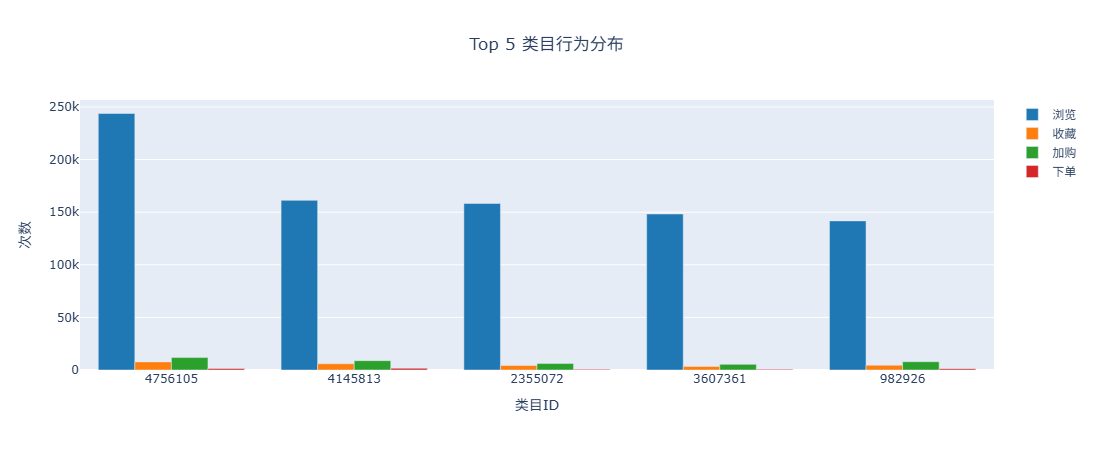

In [11]:
fig = go.Figure()
for col, color in zip(['浏览','收藏','加购','下单'], ['#1f77b4','#ff7f0e','#2ca02c','#d62728']):
    fig.add_trace(go.Bar(name=col, x=cat_df['类目ID'], y=cat_df[col], marker_color=color))

fig.update_layout(title='Top 5 类目行为分布', title_x=0.5, height=450,
                  xaxis_title='类目ID', yaxis_title='次数', barmode='group')
fig.show()